In [26]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose  import  ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

In [27]:
cars= pd.read_csv('data_files/car_sales_data.csv')
cars

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101
...,...,...,...,...,...,...,...
49995,BMW,M5,5.0,Petrol,2018,28664,113006
49996,Toyota,Prius,1.8,Hybrid,2003,105120,9430
49997,Ford,Mondeo,1.6,Diesel,2022,4030,49852
49998,Ford,Focus,1.0,Diesel,2016,26468,23630


In [28]:
corr_matrix = cars.corr(numeric_only=True)
corr_matrix["Price"].sort_values(ascending=False)



Price                  1.000000
Year of manufacture    0.714209
Engine size            0.398371
Mileage               -0.632692
Name: Price, dtype: float64

In [29]:
cars.describe()

,Engine size,Year of manufacture,Mileage,Price
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.773058,2004.209440,112497.320700,13828.903160
std,0.734108,9.645965,71632.515602,16416.681336
min,1.000000,1984.000000,630.000000,76.000000
25%,1.400000,1996.000000,54352.250000,3060.750000
50%,1.600000,2004.000000,100987.500000,7971.500000
75%,2.000000,2012.000000,158601.000000,19026.500000
max,5.000000,2022.000000,453537.000000,168081.000000


In [30]:
cars['YOM_cat']=pd.cut(
    cars['Year of manufacture'],
    bins=[1980,1996,2004,2012,2022],
    labels=[1,2,3,4]
)
cars['YOM_cat'].value_counts()

YOM_cat
1    12990
3    12388
4    12373
2    12249
Name: count, dtype: int64

In [31]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2,random_state=42)
for train_index,test_index in split.split(cars,cars['YOM_cat']):
    strat_train_set = cars.loc[train_index].drop('YOM_cat',axis=1)
    strat_test_set = cars.loc[test_index].drop('YOM_cat',axis=1)

In [32]:
car=strat_train_set.copy()
car


,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
6764,Toyota,Yaris,1.4,Petrol,1998,129790,3164
41756,VW,Golf,2.0,Diesel,2008,87468,11160
7354,VW,Golf,2.0,Petrol,1999,172920,2987
25979,Porsche,718 Cayman,2.0,Petrol,2006,107197,12808
2961,Ford,Mondeo,1.4,Diesel,2011,102212,12097
...,...,...,...,...,...,...,...
31131,VW,Golf,1.8,Petrol,1998,249902,1335
7449,Ford,Mondeo,1.8,Petrol,2010,87907,13549
25769,Toyota,Prius,1.8,Hybrid,2011,107067,15844
34453,Porsche,718 Cayman,2.0,Petrol,2003,142823,7951


In [33]:
car_labels=car['Price'].copy()
car_features= car.drop('Price',axis=1)

In [34]:
num_attribs=['Engine size', 'Year of manufacture', 'Mileage']
cat_attribs=['Manufacturer', 'Model','Fuel type',  ]

In [35]:
num_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

cat_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat',cat_pipeline, cat_attribs)
])
car_prepared = full_pipeline.fit_transform(car_features)

In [36]:
rfg=RandomForestRegressor()
rfg.fit(car_prepared,car_labels)
rfg_preds= rfg.predict(car_prepared)
rfg_rmse = root_mean_squared_error(car_labels, rfg_preds)
print("Training RMSE:", rfg_rmse)

Training RMSE: 244.43589553965884


In [ ]:
car_labels_test = strat_test_set['Price'].copy()
car_features_test = strat_test_set.drop('Price', axis=1)


In [38]:
# testing the model using metrics

mae = mean_absolute_error(car_labels_test, test_preds)
mse = mean_squared_error(car_labels_test, test_preds)
rmse = np.sqrt(mse)
r2 = r2_score(car_labels_test, test_preds)

print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

MAE  : 292.139
MSE  : 432782.426
RMSE : 657.862
R²   : 0.998


In [39]:
# testing the overfitting of model
train_preds = rfg.predict(car_prepared)

print("Train R²:", r2_score(car_labels, train_preds))
print("Test  R²:", r2_score(car_labels_test, test_preds))

Train R²: 0.9997789718853357
Test  R²: 0.9983743383309509


num__Year of manufacture     0.619442
num__Engine size             0.259020
num__Mileage                 0.039696
cat__Model_M5                0.021861
cat__Model_911               0.021561
cat__Fuel type_Petrol        0.009465
cat__Model_RAV4              0.008383
cat__Manufacturer_BMW        0.002489
cat__Manufacturer_Porsche    0.002447
cat__Model_Polo              0.001925
cat__Manufacturer_Toyota     0.001842
cat__Model_Golf              0.001606
cat__Model_Passat            0.001451
cat__Model_Prius             0.001377
cat__Model_Focus             0.001374
dtype: float64


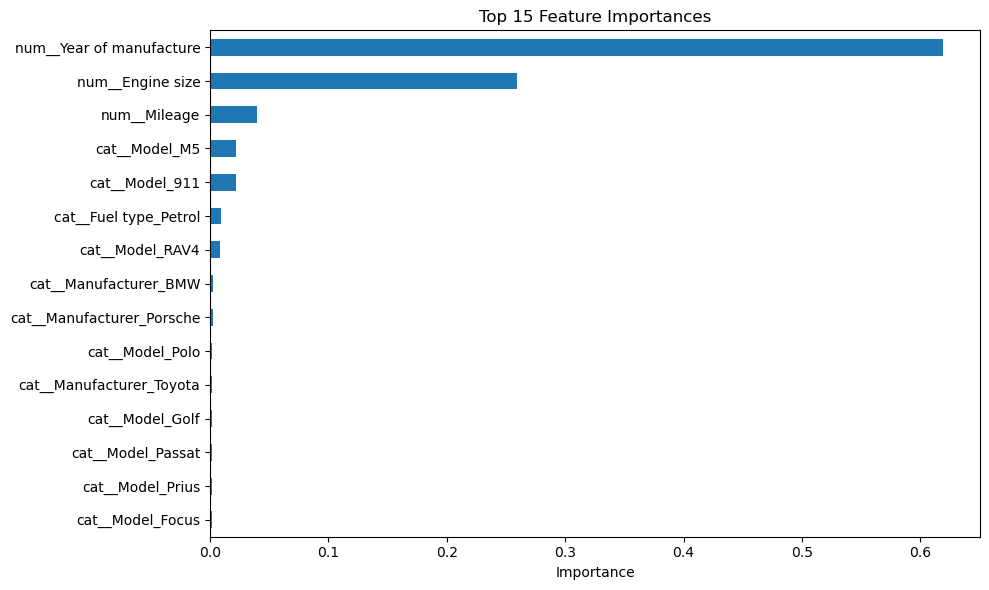

In [40]:
feature_names = full_pipeline.get_feature_names_out()

importance = pd.Series(
    rfg.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(importance.head(15))

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
importance.head(15).sort_values().plot(kind='barh')

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

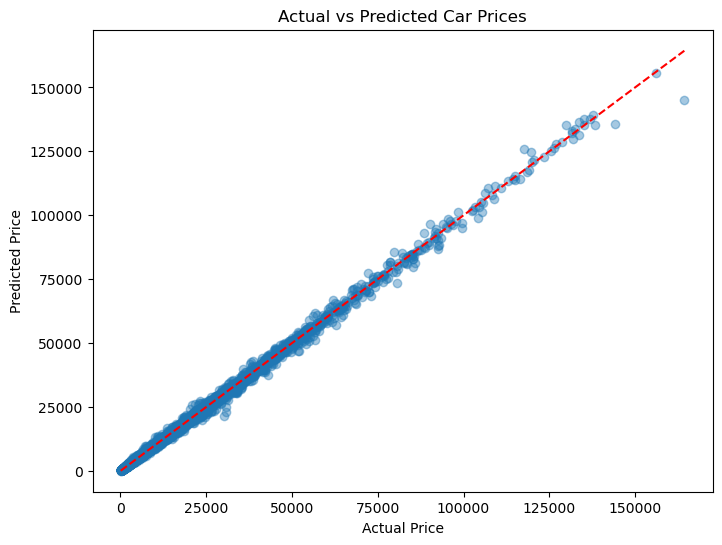

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    car_labels_test,
    test_preds,
    alpha=0.4
)

plt.plot(
    [car_labels_test.min(), car_labels_test.max()],
    [car_labels_test.min(), car_labels_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()